## A-2. Logistic Regression from Scratch

このNotebookでは、Logistic Regression（ロジスティック回帰）をPythonとNumPyを使ってゼロから実装する。

A-1のLinear Regressionでは、連続値 $y$ を予測した。

今回は、データを2つのクラスに分類する問題を考える。

例えば、

$$
y=0
$$

または

$$
y=1
$$

のような二値分類を行う。

### What we will learn

* 二値分類用のデータを生成する
* 線形モデルを定義する
* Sigmoid関数を導入する
* Binary Cross EntropyをLossとして使う
* Gradientを計算する
* Gradient Descentでパラメータを更新する
* 学習したモデルによる分類結果を可視化する

A-1と同様に、

$$
\boxed{
\text{Model}
\rightarrow
\text{Loss}
\rightarrow
\text{Gradient}
\rightarrow
\text{Parameter Update}
}
$$

という流れで学習を行う。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Generate Data

2次元のデータ $(x_1,x_2)$ を用いて、2つのクラス

$$
y=0,\qquad y=1
$$

に分類する問題を考える。

クラスごとに異なる分布を持つ人工データを生成し、これらを正しく分類できるモデルを学習する。

In [4]:
#np.random.seed(42)

N = 100

x_class0 = np.random.randn(N, 2) + np.array([-2, -2])
x_class1 = np.random.randn(N, 2) + np.array([2, 2])
# 100行×2列の乱数(~N(0,1))を生成し、クラス0は(-2,-2)に、クラス1は(2,2)にシフトさせる。

X = np.vstack([x_class0, x_class1])

y = np.hstack([
    np.zeros(N),
    np.ones(N)
])

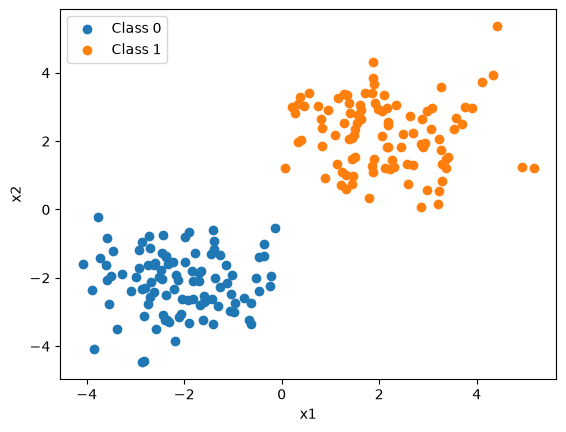

In [5]:
plt.scatter(x_class0[:, 0], x_class0[:, 1], label="Class 0")
plt.scatter(x_class1[:, 0], x_class1[:, 1], label="Class 1")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

### 4. Linear Model

A-1と同様に、まず線形モデルを考える。

$$
z=w_1x_1+w_2x_2+b
$$

ここで、$w_1,w_2$ は重み、$b$ はバイアスである。

この $z$ を後でSigmoid関数に入力し、$0$〜$1$ の値に変換する。


In [12]:
w = np.zeros(2)
b = 0.0

z = X @ w + b

print(z[:5])

[0. 0. 0. 0. 0.]


### 5. Sigmoid Function

線形モデルの出力 $z$ を $0$〜$1$ の値に変換するため、Sigmoid関数を用いる。

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

この値をクラス1である確率として解釈する。

$$
\hat{y}=\sigma(z)
$$

In [13]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

y_pred = sigmoid(z)

print(y_pred[:5])

[0.5 0.5 0.5 0.5 0.5]


### 6. Binary Cross Entropy

予測値 $\hat{y}$ と正解ラベル $y$ の誤差を評価するため、Binary Cross EntropyをLossとして用いる。

$$
L
=
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

正しい分類ほどLossは小さくなり、間違った分類ほどLossは大きくなる。


In [14]:
eps = 1e-15

y_pred_clipped = np.clip(y_pred, eps, 1 - eps)

loss = -np.mean(
    y * np.log(y_pred_clipped) +
    (1 - y) * np.log(1 - y_pred_clipped)
)

print(loss)

0.6931471805599452


### 7. Gradient

Lossを小さくするために、$w$ と $b$ に関するGradientを計算する。

$$
\frac{\partial L}{\partial w_1},
\qquad
\frac{\partial L}{\partial w_2},
\qquad
\frac{\partial L}{\partial b}
$$

Gradientは、それぞれのパラメータをどちらの方向に動かすとLossが増減するかを表す。

In [15]:
grad_w = (1 / N) * X.T @ (y_pred - y)
grad_b = (1 / N) * np.sum(y_pred - y)

print("grad_w =", grad_w)
print("grad_b =", grad_b)

grad_w = [-2.12190649 -2.00473266]
grad_b = 0.0


### 8. Parameter Update

Gradientを使って、Lossが小さくなる方向にパラメータを更新する。

$$
w
\leftarrow
w-\eta\frac{\partial L}{\partial w}
$$

$$
b
\leftarrow
b-\eta\frac{\partial L}{\partial b}
$$

ここで $\eta$ はLearning Rateである。


In [16]:
learning_rate = 0.1

w -= learning_rate * grad_w
b -= learning_rate * grad_b

print("w =", w)
print("b =", b)

w = [0.21219065 0.20047327]
b = 0.0


### 9. Train the Model

Gradient Descentを繰り返し、Lossを最小化するように $w$ と $b$ を更新する。

各ステップで

$$
X
\rightarrow z
\rightarrow \hat{y}
\rightarrow L
\rightarrow \nabla L
\rightarrow w,b\ \text{update}
$$

を行う。


w = [1.7956393  2.06074439]
b = 0.062170204004266
final loss = 0.009059685826927845


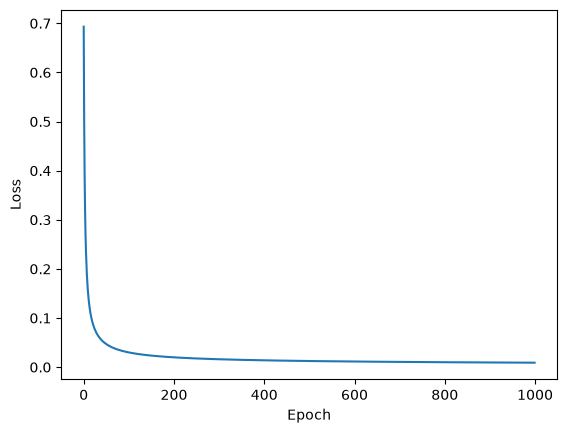

In [20]:
w = np.zeros(2)
b = 0.0

learning_rate = 0.1
epochs = 1000

loss_history = []

for _ in range(epochs):

    # Model
    z = X @ w + b
    y_pred = sigmoid(z)

    # Loss
    eps = 1e-15
    y_pred_clipped = np.clip(y_pred, eps, 1 - eps)

    loss = -np.mean(
        y * np.log(y_pred_clipped)
        + (1 - y) * np.log(1 - y_pred_clipped)
    )

    # Gradient
    grad_w = (1 / len(y)) * X.T @ (y_pred - y)
    grad_b = (1 / len(y)) * np.sum(y_pred - y)

    # Update
    w -= learning_rate * grad_w
    b -= learning_rate * grad_b

    loss_history.append(loss)

print("w =", w)
print("b =", b)
print("final loss =", loss_history[-1])

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## 11. Classification

予測確率 $\hat{y}$ を0.5を境に分類する。

$$
\hat{y}\geq0.5 \Rightarrow \text{Class 1}
$$

$$
\hat{y}<0.5 \Rightarrow \text{Class 0}
$$

Accuracy = 0.995


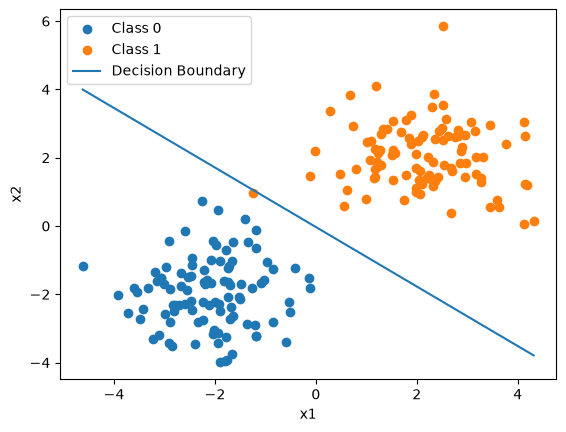

In [22]:
z = X @ w + b
y_pred = sigmoid(z)

y_class = (y_pred >= 0.5).astype(int)

accuracy = np.mean(y_class == y)

print("Accuracy =", accuracy)

plt.scatter(
    x_class0[:, 0],
    x_class0[:, 1],
    label="Class 0"
)

plt.scatter(
    x_class1[:, 0],
    x_class1[:, 1],
    label="Class 1"
)

# Decision boundary:
# w1*x1 + w2*x2 + b = 0

x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2 = -(w[0] * x1 + b) / w[1]

plt.plot(x1, x2, label="Decision Boundary")

plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()